## **Experiment 07 :** Training and Performance Analysis of Feedforward Neural Networks using the Backpropagation Algorithm

**Course:** ICE 4111: Artificial Intelligence Lab

**Student Name:** ___Prity Ghosh___________________  
**Student ID:** _0812310105171016_____________________  
**Date of Submission:** ____11.10.2026__________________

### Dataset
**Fashion-MNIST** (`tf.keras.datasets.fashion_mnist`): 70,000 grayscale images (28x28 pixels, flattened to 784 features) of clothing items from Zalando, in 10 classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot. It has the same size and format as MNIST but is a harder problem. The data downloads automatically on first run (internet needed, e.g. Colab/Kaggle).

### Objective
Train a two-hidden-layer feedforward network with backpropagation (Adam optimizer, early stopping), then analyse learning curves, classification report, confusion matrix and misclassified samples.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

print("Setup complete. You can start the experiment.")

Setup complete. You can start the experiment.


In [ ]:
# Load Fashion-MNIST and scale pixel values to [0, 1]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

(X_full, y_full), (X_test_img, y_test_int) = tf.keras.datasets.fashion_mnist.load_data()

X_full = X_full.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test_img.reshape(-1, 784).astype("float32") / 255.0

print("Train+val shape:", X_full.shape)
print("Test shape     :", X_test.shape)
print("Class counts (train):", np.bincount(y_full))
print("Pixel range: [{:.2f}, {:.2f}]".format(X_full.min(), X_full.max()))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train+val shape: (60000, 784)
Test shape     : (10000, 784)
Class counts (train): [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
Pixel range: [0.00, 1.00]


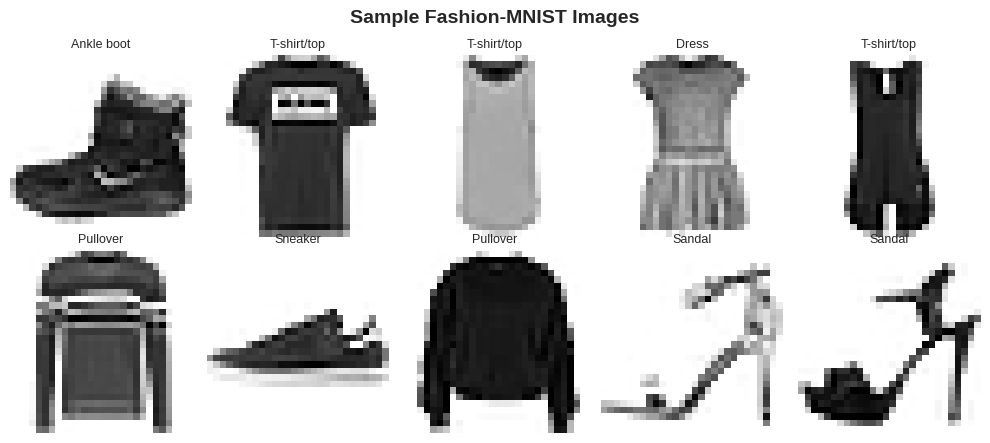

In [ ]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_full[i].reshape(28, 28), cmap="gray_r")
    ax.set_title(class_names[y_full[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample Fashion-MNIST Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# One-hot labels and train/validation split
y_train_full = tf.keras.utils.to_categorical(y_full, 10)
y_test = tf.keras.utils.to_categorical(y_test_int, 10)

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_train_full, test_size=0.1, random_state=42, stratify=y_full
)

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Train shape     : (54000, 784)
Validation shape: (6000, 784)
Test shape      : (10000, 784)


In [ ]:
# Build the feedforward neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train with early stopping (backpropagation)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
)
print(f"Training finished after {len(history.history['loss'])} epochs.")

Training finished after 19 epochs.


In [ ]:
# Evaluate on the test set
test_probabilities = model.predict(X_test, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_true = y_test_int

print(f"Test Accuracy : {accuracy_score(test_true, test_predictions):.4f}")
print(classification_report(test_true, test_predictions, target_names=class_names))

Test Accuracy : 0.8835
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.80      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.83      0.76      0.79      1000
       Dress       0.85      0.92      0.89      1000
        Coat       0.81      0.80      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.68      0.73      0.71      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



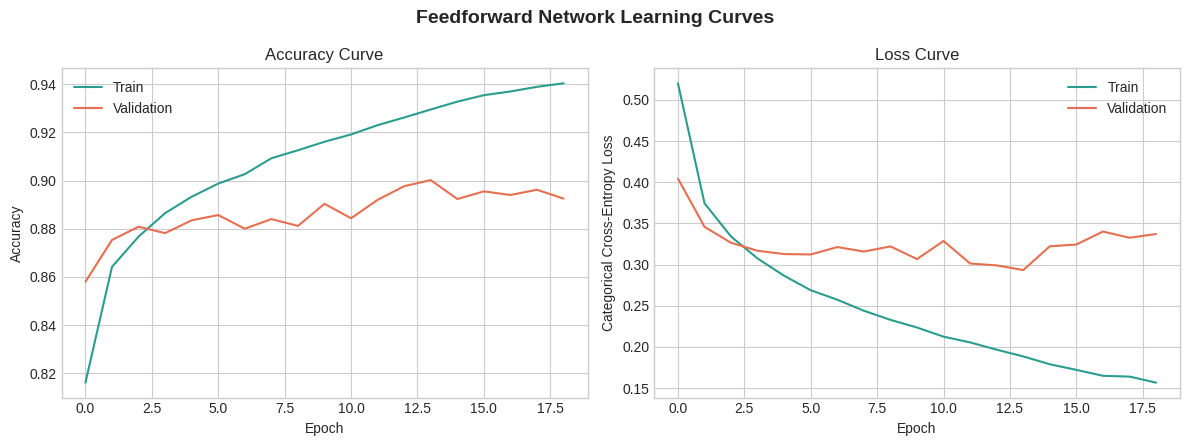

In [ ]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history.history["accuracy"], label="Train", color="#2a9d8f")
axes[0].plot(history.history["val_accuracy"], label="Validation", color="#e76f51")
axes[0].set_title("Accuracy Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="Train", color="#2a9d8f")
axes[1].plot(history.history["val_loss"], label="Validation", color="#e76f51")
axes[1].set_title("Loss Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Categorical Cross-Entropy Loss"); axes[1].legend()

plt.suptitle("Feedforward Network Learning Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

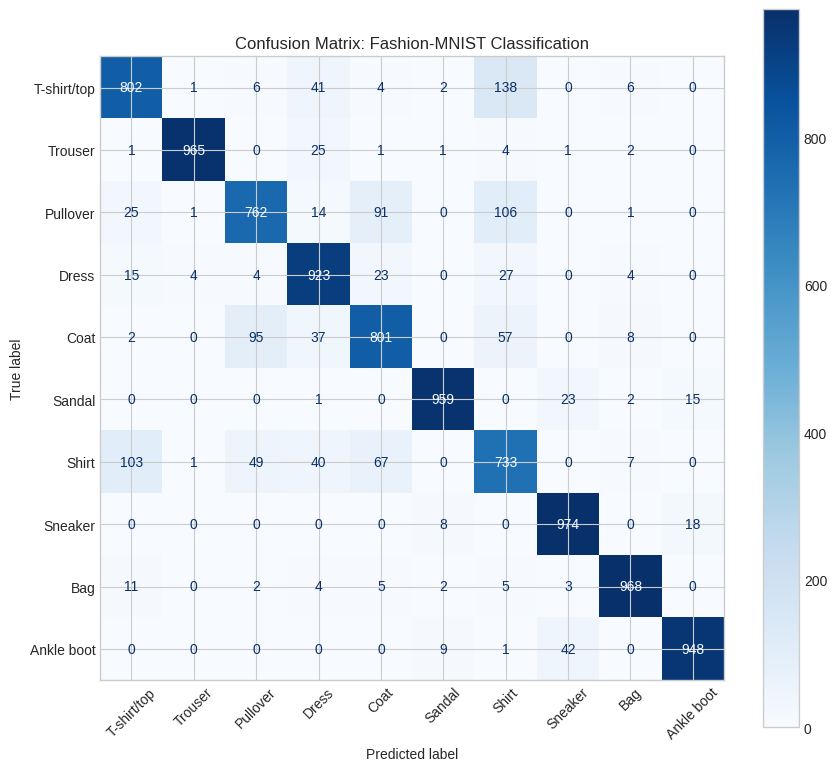

In [ ]:
# Confusion matrix
cm = confusion_matrix(test_true, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(cmap="Blues", ax=ax, colorbar=True, values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix: Fashion-MNIST Classification")
plt.tight_layout()
plt.show()

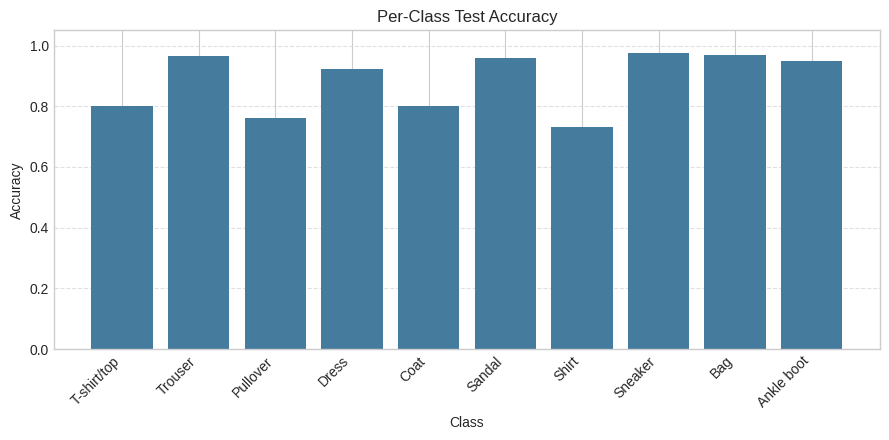

Hardest class: Shirt (73.30%)


In [ ]:
# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(9, 4.5))
plt.bar(range(10), per_class_accuracy, color="#457b9d")
plt.xlabel("Class"); plt.ylabel("Accuracy"); plt.title("Per-Class Test Accuracy")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

worst = np.argmin(per_class_accuracy)
print(f"Hardest class: {class_names[worst]} ({per_class_accuracy[worst]:.2%})")

Correctly classified : 8835 / 10000
Misclassified        : 1165 / 10000


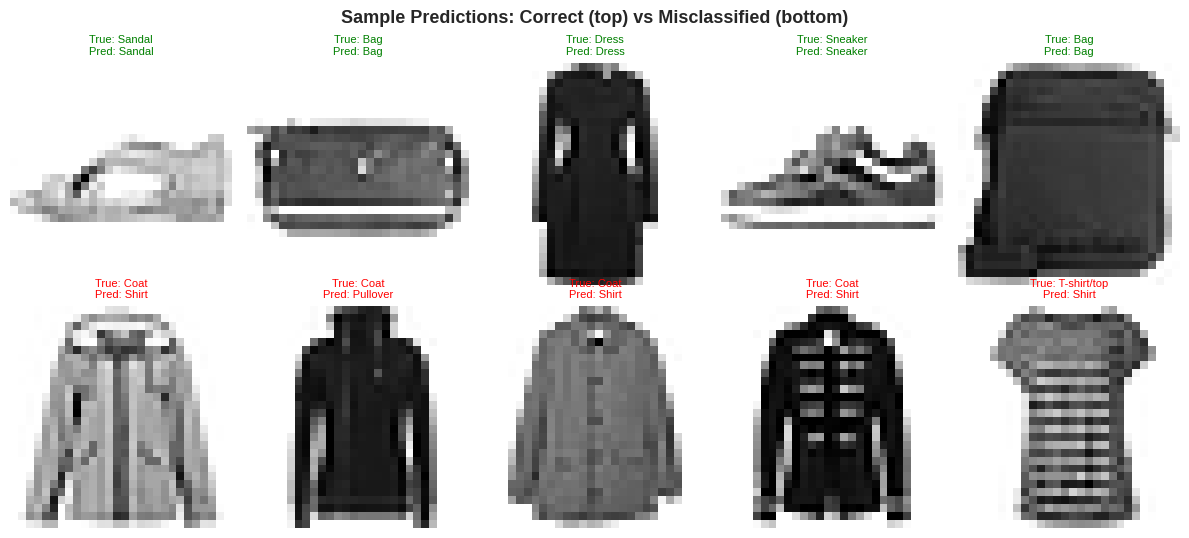

In [ ]:
# Correct vs misclassified predictions
misclassified = np.where(test_predictions != test_true)[0]
correct = np.where(test_predictions == test_true)[0]

print(f"Correctly classified : {len(correct)} / {len(test_true)}")
print(f"Misclassified        : {len(misclassified)} / {len(test_true)}")

sample_correct = np.random.choice(correct, size=5, replace=False)
sample_wrong = np.random.choice(misclassified, size=5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, idx in zip(axes[0], sample_correct):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"True: {class_names[test_true[idx]]}\nPred: {class_names[test_predictions[idx]]}", fontsize=8, color="green")
    ax.axis("off")
for ax, idx in zip(axes[1], sample_wrong):
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"True: {class_names[test_true[idx]]}\nPred: {class_names[test_predictions[idx]]}", fontsize=8, color="red")
    ax.axis("off")

plt.suptitle("Sample Predictions: Correct (top) vs Misclassified (bottom)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## **Exercises**
1. Change hidden units (e.g. 128/64) and compare test accuracy.
2. Try `tanh` instead of `relu`.
3. Add `Dropout(0.3)` after each hidden layer and compare the train/validation gap (Fashion-MNIST overfits more than MNIST).
4. Which classes are confused most often (e.g. Shirt vs T-shirt/top)? Explain why from the images.